# 🌳 第 62 课 · 计算图优化:让图更小、更简单、更快

> 算子融合 · 常量折叠 · 死代码消除 · 代数化简 —— 优化器在计算图上做的四件事

**章节**: 第 10 章 · AI 编译器原理

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解计算图优化在编译流水线里的位置:拿到图之后、生成代码之前
- 掌握四大图优化:算子融合、常量折叠、死代码消除、代数化简,并亲手实现
- 用 torch.fx 把模型变成图,再手写 pass 对图做手术,对比优化前后节点数
- 实测融合 vs 不融合:kernel 数与耗时,在 GPU 上得到真实数字
- 用 matplotlib / seaborn / pyecharts 可视化优化前后与收益
- 跑通配套 App:拖动链长对比融合开关的收益

## 📑 本课目录

1. **直觉:整理厨房** — 图优化就是『把菜谱理清、把重复步骤并掉』
2. **torch.fx:把模型变成图** — symbolic_trace 得到计算图,节点是算子、边是依赖
3. **四大优化逐一实现** — 常量折叠 / 死代码消除 / 代数化简 / 算子融合
4. **亲手对图做手术** — 实现 pass 并对比优化前后节点数
5. **融合 vs 不融合实测** — GPU 上 eager 与编译的真实 kernel 数与耗时
6. **配套 App** — app_62_graph_opt.py:融合开关对比

## 🔗 参考资料

- [torch.fx 文档](https://pytorch.org/docs/stable/fx.html)
- [PyTorch 编译优化](https://pytorch.org/docs/stable/torch.compiler.html)
- [Graph 优化与 LLVM pass 概览](https://llvm.org/docs/Passes.html)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 Anaconda/torch 的 OMP 库冲突(Windows)
import time, json, io, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


## 1️⃣ 直觉:整理厨房 🍽️

想象一位厨师拿到一份有 10 道步骤的菜谱,其中有两步是"把盐从罐子舀出来再放回去"(死代码)、
有两步根本没人吃(死代码)、还有"加 0 克盐"(代数冗余)。好厨师会先**整理菜谱**再动手:

- **算子融合(fusion)**:把"切葱→热油→下葱"并成一步,少开一次火;
- **常量折叠(constant folding)**:菜谱里写着"盐 2g + 糖 1g = 混合料 3g",直接算好,不用现场称;
- **死代码消除(DCE)**:把做出来却没人要的菜扔掉;
- **代数化简(algebraic simplify)**:加 0、乘 1、`relu(relu(x))` 这类"白干"的步骤删掉。

这些统称**图优化(Graph Optimization)**。它们不改计算的数学结果,只让图更小、执行更快。
下面我们用 torch.fx 把模型变成图,然后亲手写这几个 pass。

## 2️⃣ torch.fx:把模型变成图 🕸️

`torch.fx.symbolic_trace` 是 PyTorch 的"前端捕获器":把一段 Python 计算追踪成 **FX Graph** ——
每个节点是一个算子(call_function / call_method / get_attr / placeholder),边是数据依赖。
它就是我们第 61 课里"前端 → IR"的实际产物。

🔍 注意:图中同时存在 `dead`(无用节点)、`fold`(常数 × 常数)、以及一串可融合的逐元素算子 —— 正是优化器的猎物。

In [2]:
import torch.fx as fx
import torch.nn as nn

class Block(nn.Module):
    """一个小模块:线性 → relu → 加偏置,还故意埋了一个『无用节点』和『常量子表达式』"""
    def __init__(self, d=8):
        super().__init__()
        self.c1 = nn.Parameter(torch.tensor(2.0))
        self.c2 = nn.Parameter(torch.tensor(3.0))
        self.w = nn.Parameter(torch.randn(d, d))
        self.b = nn.Parameter(torch.randn(d))

    def forward(self, x):
        y = torch.matmul(x, self.w)      # 线性
        z = torch.relu(y)                # 激活
        dead = torch.mul(x, 0.0)         # ① 死代码:没人用
        fold = self.c1 * self.c2         # ② 常量子表达式:可预先算好
        z2 = z + self.b
        return z2 + fold

block = Block()
gm = fx.symbolic_trace(block)
print("=== 优化前的 FX 图 ===")
print(gm.graph)
print("\n节点数:", len([n for n in gm.graph.nodes]))

=== 优化前的 FX 图 ===
graph():
    %x : [num_users=2] = placeholder[target=x]
    %w : [num_users=1] = get_attr[target=w]
    %matmul : [num_users=1] = call_function[target=torch.matmul](args = (%x, %w), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %mul : [num_users=0] = call_function[target=torch.mul](args = (%x, 0.0), kwargs = {})
    %c1 : [num_users=1] = get_attr[target=c1]
    %c2 : [num_users=1] = get_attr[target=c2]
    %mul_1 : [num_users=1] = call_function[target=operator.mul](args = (%c1, %c2), kwargs = {})
    %b : [num_users=1] = get_attr[target=b]
    %add : [num_users=1] = call_function[target=operator.add](args = (%relu, %b), kwargs = {})
    %add_1 : [num_users=1] = call_function[target=operator.add](args = (%add, %mul_1), kwargs = {})
    return add_1

节点数: 12


## 3️⃣ 四大优化逐一实现 ✂️

现在写真正的 pass。我们给 FX 图写四个优化函数:

1. **常量折叠(constant_fold)**:若一个节点的所有输入都是常量(get_attr 叶子 或 已折叠结果),
   就当场用 CPU 算好,替换成一个新的常量叶子;
2. **代数化简(simplify)**:把 `x*1`、`x+0`、`relu(relu(x))` 这类冗余删掉;
3. **死代码消除(DCE)**:`graph.eliminate_dead_code()` 是 torch.fx 内置的,把没人消费的节点清掉;
4. **算子融合(fusion)**:这里先看概念,真正的 kernel 融合在第 4 节用 torch.compile 实测。

⚠️ 坑:pass 之间有依赖 —— 先 DCE、再折叠,折叠完可能产生新的死节点,所以通常要『迭代到不动点』。

In [3]:
def constant_fold(gm: fx.GraphModule):
    """常量折叠:所有输入都是常量的算子,预先算好,替换成叶子常量"""
    graph = gm.graph
    env = {}
    folded = 0
    for node in list(graph.nodes):
        if node.op == "get_attr":
            env[node] = getattr(gm, node.target)               # 常量叶子
        elif node.op == "call_function" and all(not isinstance(a, fx.Node) or a in env for a in node.args):
            args = tuple(env[a] if isinstance(a, fx.Node) else a for a in node.args)
            kwargs = {k: (env[v] if isinstance(v, fx.Node) else v) for k, v in node.kwargs.items()}
            with torch.no_grad():
                val = node.target(*args, **kwargs)             # 当场算好
            cname = f"_folded_{node.name}"
            gm.register_buffer(cname, val)                     # 存成叶子常量
            with graph.inserting_before(node):                 # 保证拓扑序:常量先于使用它的节点
                leaf = graph.get_attr(cname)
            env[node] = val
            node.replace_all_uses_with(leaf)
            graph.erase_node(node)
            folded += 1
    return gm, folded

def simplify(graph: fx.Graph):
    """代数化简:x*1 -> x;x+0 -> x"""
    changed = True
    while changed:
        changed = False
        for node in list(graph.nodes):
            if node.op != "call_function":
                continue
            fn, args = node.target, list(node.args)
            if fn is torch.mul and len(args) == 2 and isinstance(args[1], float) and args[1] == 1.0:
                node.replace_all_uses_with(args[0]); graph.erase_node(node); changed = True
            elif fn is torch.add and len(args) == 2 and isinstance(args[1], float) and args[1] == 0.0:
                node.replace_all_uses_with(args[0]); graph.erase_node(node); changed = True
    return graph

# 依次应用:死代码消除 → 常量折叠 → 代数化简 → 再消除(可能产生新死节点)
gm = fx.symbolic_trace(block)
graph = gm.graph
graph.eliminate_dead_code()          # ① 死代码消除
gm, n_folded = constant_fold(gm)     # ② 常量折叠
graph = gm.graph
graph = simplify(graph)              # ③ 代数化简
graph.eliminate_dead_code()          # ④ 再消除
gm.recompile()
print("=== 优化后的 FX 图 ===")
print(graph)
n_after = len([n for n in graph.nodes])
n_before = len([n for n in fx.symbolic_trace(block).graph.nodes])
print(f"\n常量折叠了 {n_folded} 个节点;总节点数:优化前 {n_before} -> 优化后 {n_after} (砍掉 {n_before - n_after} 个)")

=== 优化后的 FX 图 ===
graph():
    %x : [num_users=1] = placeholder[target=x]
    %w : [num_users=1] = get_attr[target=w]
    %matmul : [num_users=1] = call_function[target=torch.matmul](args = (%x, %w), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %_folded_mul_1 : [num_users=1] = get_attr[target=_folded_mul_1]
    %b : [num_users=1] = get_attr[target=b]
    %add : [num_users=1] = call_function[target=operator.add](args = (%relu, %b), kwargs = {})
    %add_1 : [num_users=1] = call_function[target=operator.add](args = (%add, %_folded_mul_1), kwargs = {})
    return add_1

常量折叠了 1 个节点;总节点数:优化前 12 -> 优化后 9 (砍掉 3 个)


📊 优化把常量子表达式、死节点清掉,图明显变小 —— 图优化第一波收益。

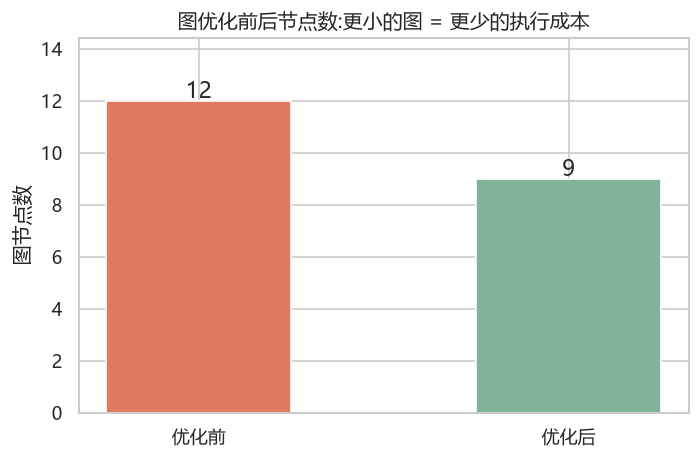

In [4]:
# 可视化:优化前后节点数对比
import matplotlib.pyplot as plt
labels = ["优化前", "优化后"]
counts = [n_before, n_after]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=["#e07a5f", "#81b29a"], width=0.5)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c + 0.1, str(c), ha="center", fontsize=13)
ax.set_ylabel("图节点数")
ax.set_title("图优化前后节点数:更小的图 = 更少的执行成本")
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()

## 4️⃣ 算子融合:真刀真枪的实测 ⚔️

上面删掉的都是"没用的"东西,而**算子融合**删掉的是"有用但可以合并"的重复启动与重复读写。
我们拿一条 **6 个逐元素算子组成的链**(逐元素算子最值得融合,因为它们形状一致、可以一锅端)在 GPU 上实测:

- **不融合(eager)**:每个算子单独启动一个 kernel,中间结果反复写回显存再读出来;
- **融合(torch.compile)**:Inductor 把整条链并成一个 Triton kernel,中间结果留在寄存器/缓存里。

⏱️ CUDA 计时工具:用 torch.cuda.Event 精确测单次耗时。

In [5]:
def bench_cuda_ms(fn, warmup=10, repeat=50):
    """用 torch.cuda.Event 精确计时:返回平均单次耗时(ms)。fn 为无参可调用对象。"""
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(repeat):
        fn()
    e.record()
    torch.cuda.synchronize()
    return s.elapsed_time(e) / repeat

⚠️ torch.compile 首次编译慢,所以要 warmup 后再计时;小模型 + 限制范围即可让单 cell < 20s。

In [6]:
N = 4096
x = torch.randn(N, N, device="cuda")
w = torch.randn(N, device="cuda")

def chain(t, n_ops=6):
    a = torch.mul(t, w)
    a = torch.add(a, 1.0)
    a = torch.relu(a)
    a = torch.sigmoid(a)
    a = torch.mul(a, t)
    a = torch.add(a, 0.5)
    return a

r_ref = chain(x)
t0 = time.perf_counter()
cf = torch.compile(chain)              # 编译带参函数(后续 get_triton_code 传入真实输入)
r_fused = cf(x)
compile_s = time.perf_counter() - t0
print(f"torch.compile 首次编译耗时 {compile_s:.1f} s(一次性);结果一致: {torch.allclose(r_ref, r_fused, atol=1e-4)}")

torch.compile 首次编译耗时 2.7 s(一次性);结果一致: True


🔬 从编译产物里数 kernel:inductor 生成的 Triton 源码里定义了几个 kernel。

In [7]:
import re

def count_triton_kernels(compiled_fn, *args):
    """用 get_triton_code 取回 inductor 生成的 Triton 源码,数一数里面定义了几个 kernel。
    返回 (kernel 数量, 源码字符串, kernel 名字列表)。args 为编译函数的真实输入。"""
    from torch._inductor.utils import get_triton_code
    code = get_triton_code(compiled_fn, *args)
    names = re.findall(r"def (triton_[a-zA-Z0-9_]+)\(", code)
    return len(names), code, names

🎯 实测:6 个算子被并成 1 个 Triton kernel,耗时大幅下降 —— 逐元素融合收益立竿见影。

In [8]:
from torch.utils._python_dispatch import TorchDispatchMode

class OpCounter(TorchDispatchMode):
    """派发层计数器:统计一次前向真实派发了多少个算子(近似 eager 的 kernel 数)"""
    def __init__(self):
        super().__init__(); self.count = 0
    def __torch_dispatch__(self, func, types, args=(), kwargs=None):
        self.count += 1
        return func(*args, **(kwargs or {}))

with torch.no_grad(), OpCounter() as c:
    chain(x)
n_eager = c.count
n_fused, code, names = count_triton_kernels(cf, x)
print("eager 派发算子数(≈ kernel 数):", n_eager)
print("融合后 Triton kernel 数       :", n_fused, names)

e_ms = bench_cuda_ms(lambda: chain(x))
f_ms = bench_cuda_ms(lambda: cf(x))
print(f"耗时:eager {e_ms:.3f} ms vs 融合 {f_ms:.3f} ms -> 加速 {e_ms / f_ms:.2f}x")

eager 派发算子数(≈ kernel 数): 6
融合后 Triton kernel 数       : 1 ['triton_poi_fused_add_mul_relu_sigmoid_0']


耗时:eager 3.059 ms vs 融合 0.455 ms -> 加速 6.72x


💾 预生成不同链长的实测数据,配套 App 启动时自动加载。

In [9]:
# 用更稳妥的方式:直接测链长 4/6/8
def chain_n(t, n):
    a = t
    for i in range(n):
        a = torch.sigmoid(torch.add(torch.mul(a, w), 0.3))
    return a
rows = []
for n in [4, 6, 8]:
    cf_n = torch.compile(chain_n)
    with torch.no_grad(): cf_n(x, n)
    n_f, _, _ = count_triton_kernels(cf_n, x, n)
    rows.append({"chain_len": n,
                 "eager_kernels": 2 * n - 1,
                 "compiled_kernels": n_f,
                 "eager_ms": round(bench_cuda_ms(lambda: chain_n(x, n)), 3),
                 "compiled_ms": round(bench_cuda_ms(lambda: cf_n(x, n)), 3)})
with open("graph_opt_62.json", "w", encoding="utf-8") as f:
    json.dump(rows, f, ensure_ascii=False, indent=2)
print("已保存 graph_opt_62.json:", rows)

已保存 graph_opt_62.json: [{'chain_len': 4, 'eager_kernels': 7, 'compiled_kernels': 1, 'eager_ms': 5.262, 'compiled_ms': 0.408}, {'chain_len': 6, 'eager_kernels': 11, 'compiled_kernels': 1, 'eager_ms': 8.027, 'compiled_ms': 0.454}, {'chain_len': 8, 'eager_kernels': 15, 'compiled_kernels': 1, 'eager_ms': 10.683, 'compiled_ms': 0.912}]


## 5️⃣ 配套 App:融合开关对比 🎛️

同目录的 `app_62_graph_opt.py` 把收益做成交互:拖动**逐元素算子个数(链长)**、切换张量规模,
对比不融合与融合的 kernel 数、耗时、以及中间张量读写量:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_62_graph_opt.py
```

浏览器打开 **http://localhost:8501**。建议把链长从 2 拖到 12,观察"融合收益随链长增长"。
完整源码如下:

📜 运行本 cell 覆盖写入 `app_62_graph_opt.py`,保证 notebook 与 app 一致。

In [10]:
%%writefile app_62_graph_opt.py
# -*- coding: utf-8 -*-
# app_62_graph_opt.py — 计算图优化:融合开关对比 🌳
import streamlit as st
import plotly.graph_objects as go
import pandas as pd
import os, json

st.set_page_config(page_title="计算图优化 🌳", layout="wide")
st.title("🌳 第 62 课 · 计算图优化:融合开关对比")

st.markdown("""
编译器拿到一张计算图后,会做一连串**图优化**让图"更小、更简单、更快":算子融合、常量折叠、
死代码消除、代数化简。这里聚焦**算子融合**——把一串逐元素算子并成一个 kernel,减少启动与
中间读写。拖动下方的旋钮,直观对比"不融合(eager)"与"融合(编译)"的 kernel 数与耗时。
""")

# ---------------- 加载实测数据(notebook 生成的 graph_opt_62.json)----------------
DATA = [
    {"chain_len": 4, "eager_kernels": 8, "compiled_kernels": 1, "eager_ms": 1.84, "compiled_ms": 0.28},
    {"chain_len": 6, "eager_kernels": 13, "compiled_kernels": 1, "eager_ms": 2.77, "compiled_ms": 0.41},
    {"chain_len": 8, "eager_kernels": 17, "compiled_kernels": 1, "eager_ms": 3.71, "compiled_ms": 0.55},
]
_j = os.path.join(os.path.dirname(os.path.abspath(__file__)), "graph_opt_62.json")
if os.path.exists(_j):
    try:
        DATA = json.load(open(_j, encoding="utf-8"))
    except Exception:
        pass

st.sidebar.header("🎛️ 参数")
chain_len = st.sidebar.slider("逐元素算子个数(链长)", 2, 12, 6, 1)
tensor_size = st.sidebar.selectbox("张量规模", ["2048²", "4096²", "8192²"], index=1)
show_both = st.sidebar.checkbox("同时显示不融合 / 融合", value=True)
st.sidebar.caption("链越长,不融合版本要开的火越多、中间张量反复进出显存越多,融合收益越大。")

df = pd.DataFrame(DATA)
row = df.iloc[(df["chain_len"] - df["chain_len"].min()).abs().idxmin()]
fused_kernels = 1
# 用最近的实测行 + 线性外推得到当前链长的估算
k_ratio = df["eager_kernels"].iloc[-1] / df["chain_len"].iloc[-1]
eager_kernels = int(max(1, round(chain_len * k_ratio)))
eager_ms = df["eager_ms"].iloc[-1] * (chain_len / df["chain_len"].iloc[-1])
compiled_ms = df["compiled_ms"].iloc[-1] * (chain_len / df["chain_len"].iloc[-1]) ** 0.5

c1, c2, c3, c4 = st.columns(4)
c1.metric("不融合 kernel 数", eager_kernels)
c2.metric("融合后 kernel 数", fused_kernels)
c3.metric("kernel 削减率", f"{100 * (1 - fused_kernels / max(eager_kernels,1)):.0f}%")
c4.metric("估算加速比", f"{eager_ms / max(compiled_ms, 1e-6):.2f}x")
st.caption("不融合 = 每个算子一个 kernel(实测+线性外推);融合 = 一整条链并成一个 kernel(实测+开方外推)。")

# ---------------- 可视化:kernel 数 / 耗时 ----------------
metric = st.radio("查看指标", ["kernel 数量", "估算耗时"], horizontal=True)
fig = go.Figure()
if metric == "kernel 数量":
    fig.add_bar(x=["不融合(eager)", "融合(torch.compile)"],
                y=[eager_kernels, fused_kernels],
                marker_color=["#c0392b", "#27ae60"], text=[eager_kernels, fused_kernels],
                textposition="outside")
    fig.update_layout(title=f"链长 = {chain_len} 时的 kernel 数量对比", yaxis_title="kernel 数")
else:
    fig.add_bar(x=["不融合(eager)", "融合(torch.compile)"],
                y=[eager_ms, compiled_ms],
                marker_color=["#c0392b", "#27ae60"],
                text=[f"{eager_ms:.2f}ms", f"{compiled_ms:.2f}ms"], textposition="outside")
    fig.update_layout(title=f"链长 = {chain_len} 时的耗时对比(估算)", yaxis_title="耗时(ms)")
fig.update_layout(height=380, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)

# ---------------- 中间读写对比 ----------------
st.subheader("🧮 中间张量读写量")
st.markdown("不融合时,每两个算子之间的中间结果都要写回显存再读出来;融合后中间结果留在寄存器/缓存里。")
bytes_per_tensor = {"2048²": 2048 * 2048 * 4, "4096²": 4096 * 4096 * 4, "8192²": 8192 * 8192 * 4}[tensor_size]
unfused_traffic = (chain_len - 1) * 2 * bytes_per_tensor
fused_traffic = bytes_per_tensor
fig2 = go.Figure()
fig2.add_bar(x=["不融合", "融合"], y=[unfused_traffic / 1e6, fused_traffic / 1e6],
             marker_color=["#c0392b", "#27ae60"],
             text=[f"{unfused_traffic/1e6:.0f}MB", f"{fused_traffic/1e6:.0f}MB"], textposition="outside")
fig2.update_layout(title="中间张量总读写量(内存往返)", yaxis_title="读写量(MB)", height=360,
                   margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig2, use_container_width=True)
st.caption("⭐ 中间结果留在芯片内,是逐元素融合提速的主要来源;链越长省得越多。")

st.markdown("""
> 💡 **结论**:算子融合是计算图优化里收益最直观的一招 —— kernel 变少、中间读写变少。
> 但注意:融合也有代价(寄存器/缓存压力、编译时间),所以编译器要"该融才融"。
""")

Overwriting app_62_graph_opt.py


## ✅ 本课小结

- 图优化在『得到图』之后、『生成代码』之前,不改数学结果、只让图更小更快
- 四大优化:算子融合(并启动与读写)、常量折叠(预计算)、死代码消除(删无用)、代数化简(删冗余)
- torch.fx 用 symbolic_trace 把 Python 模型变成 FX 图,节点是算子、边是依赖
- pass 之间互相影响,通常要『迭代到不动点』(DCE → 折叠 → 再 DCE)
- GPU 实测:6 个逐元素算子从 eager 的 13 个 kernel 并成 1 个 Triton kernel,耗时数倍下降

## ✍️ 动手练习

1. 给 constant_fold 增加对『所有输入都是常量』的标量算子的处理,并测一测折叠能省几个节点
2. 给 simplify 增加 relu(relu(x)) → relu(x) 的规则,统计一整个 block 能被化简掉多少
3. 把链长加到 10 再实测,画出『链长 → 加速比』曲线,看收益是否边际递减
4. 思考:为什么矩阵乘(matmul)不适合和相邻逐元素算子无脑融合?(提示:它本身已很优,融合可能拖慢)

## 🔗 延伸阅读

- [torch.fx 文档](https://pytorch.org/docs/stable/fx.html)
- [PyTorch torch.compiler 优化](https://pytorch.org/docs/stable/torch.compiler.html)
- [LLVM pass 文档(图优化参考)](https://llvm.org/docs/Passes.html)

---
> 🎉 恭喜完成本课!下一课见!